# **Project: Cambodian Tourism Chatbot (RNN)**
---

### **1. Project Overview**

> In this project, you will build a Natural Language Processing (NLP) model using a **Simple Recurrent Neural Network (RNN)**. The goal is to create a chatbot that can answer common questions about tourism in Cambodia, covering destinations, food, and travel logistics.

---

### ⚠️ Why the original approach failed — and what we changed

The original notebook used **sequence-to-sequence word prediction** (`return_sequences=True`): the model tried to predict one output word per time step. This caused:
- **Repetition** (`"in in in in in"`, `"generally generally generally"`) because the model learns the most common word at each position rather than the actual answer.
- **No coherent answer** because predicting word-by-word independently does not produce a sentence.

**The dataset has only 71 unique answers** across 2000 questions — roughly 28 differently-phrased questions per answer. This is a **classification problem**, not a generation problem.

**Fix:** Use the RNN to read the question (`return_sequences=False` — one output at the end), then classify it into one of the 71 answer classes. The model learns *which answer to return*, not which word to generate next.

### **2. Environment Setup**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.18.1
All libraries imported successfully!


### **3. Data Acquisition & Exploration**
#### **3.1 Load Dataset**

In [17]:
df = pd.read_csv("cambodia_tourism_dataset_large.csv")
df.head(10)

,question,answer
0,can you explain where is angkor wat specifically.,angkor wat is in siem reap cambodia
1,give me details on what is angkor wat for me.,it is a famous temple in cambodia
2,hey what to do in siem reap specifically.,you can visit temples and night market
3,do you know where is bayon temple immediately.,bayon temple is in the center of angkor thom
4,do you know what is ta prohm specifically.,it is the jungle temple with giant trees in si...
5,hi how much is angkor pass thank you.,a 1-day pass is 37 dollars and a 3-day pass is...
6,do you know where to watch sunset in siem reap...,phnom bakheng is the most popular spot for sunset
7,what is pub street?,it is the nightlife hub of siem reap with bars...
8,is tonle sap near siem reap specifically.,yes it is the largest freshwater lake near sie...
9,can you tell me best time to visit temples,early morning at sunrise is the best time


#### **3.2 Dataset Analysis**

Total number of samples  : 2000
Unique questions         : 2000
Unique answers (classes) : 71

Max question length (words): 14
Max answer length  (words): 13
Avg question length (words): 8.7
Avg answer length  (words): 8.7

Key insight: only 71 unique answers → this is a CLASSIFICATION problem.


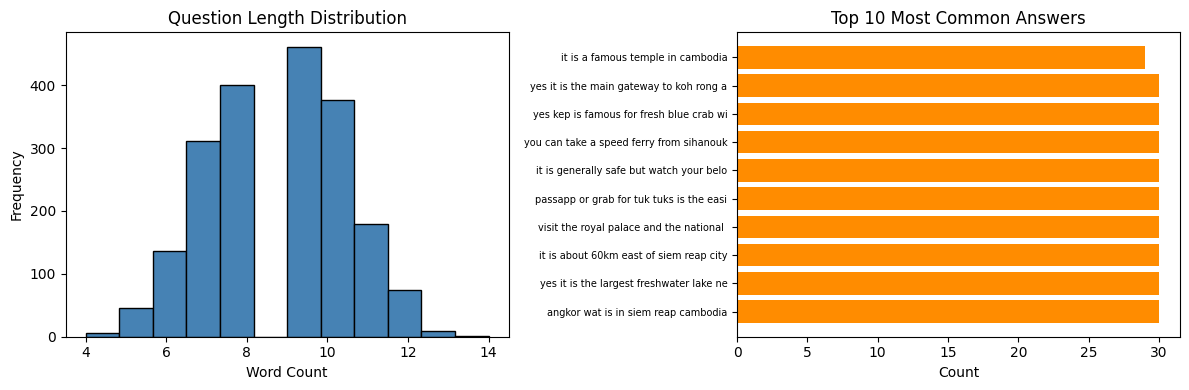

In [18]:
print(f"Total number of samples  : {len(df)}")
print(f"Unique questions         : {df['question'].nunique()}")
print(f"Unique answers (classes) : {df['answer'].nunique()}")
print()

df['question_len'] = df['question'].apply(lambda x: len(str(x).split()))
df['answer_len']   = df['answer'].apply(lambda x: len(str(x).split()))

print(f"Max question length (words): {df['question_len'].max()}")
print(f"Max answer length  (words): {df['answer_len'].max()}")
print(f"Avg question length (words): {df['question_len'].mean():.1f}")
print(f"Avg answer length  (words): {df['answer_len'].mean():.1f}")
print()
print("Key insight: only 71 unique answers → this is a CLASSIFICATION problem.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['question_len'], bins=12, color='steelblue', edgecolor='black')
axes[0].set_title('Question Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

top_answers = df['answer'].value_counts().head(10)
axes[1].barh(range(10), top_answers.values, color='darkorange')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([a[:40] for a in top_answers.index], fontsize=7)
axes[1].set_title('Top 10 Most Common Answers')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

### **4. Data Preprocessing**
#### **4.1 Tokenization — Questions only**

We tokenize only the **questions** (model input). The answers become **class labels** (integers 0–70), not sequences.

In [19]:
inputs    = df["question"].astype(str).str.lower().tolist()
responses = df["answer"].astype(str).tolist()

In [20]:
# Tokenize the QUESTIONS
tokenizer = Tokenizer(filters='', oov_token='<OOV>')
tokenizer.fit_on_texts(inputs)
vocab_size = len(tokenizer.word_index) + 1

X_seq = tokenizer.texts_to_sequences(inputs)

print(f"Total words in vocabulary: {vocab_size}")
print("Word Index Sample:", dict(list(tokenizer.word_index.items())[:10]))
print(f"\nOriginal:  {inputs[0]}")
print(f"Numerical: {X_seq[0]}")

Total words in vocabulary: 231
Word Index Sample: {'<OOV>': 1, 'is': 2, 'what': 3, 'where': 4, 'me': 5, 'you': 6, 'to': 7, 'for': 8, 'i': 9, 'in': 10}

Original:  can you explain where is angkor wat specifically.
Numerical: [14, 6, 15, 4, 2, 34, 37, 22]


#### **4.1b Label Encoding — Answers become class IDs**

Instead of tokenizing answers, we convert each unique answer string into a single integer (0 to 70). This is the **class label** the model learns to predict.

In [21]:
# Encode the 71 unique answer strings as integer class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(responses)   # shape: (2000,)

num_classes = len(label_encoder.classes_)
print(f"Number of answer classes: {num_classes}")
print()

# Store answer lookup: class_id → answer text (needed at inference time)
id_to_answer = {i: ans for i, ans in enumerate(label_encoder.classes_)}

# Preview
for i in range(4):
    print(f"  Class {y_encoded[i]:2d} → '{responses[i]}'")

Number of answer classes: 71

  Class  2 → 'angkor wat is in siem reap cambodia'
  Class 11 → 'it is a famous temple in cambodia'
  Class 66 → 'you can visit temples and night market'
  Class  4 → 'bayon temple is in the center of angkor thom'


#### **4.2 Padding**

Padding makes all question sequences the same length (`max_len = 14`) so they can be batched into a single tensor.

In [22]:
max_len = max(len(seq) for seq in X_seq)   # 14
print(f"max_len: {max_len}")

X = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')
y = y_encoded   # already a 1-D array of class integers

print(f"X shape: {X.shape}   → (samples, max_len)")
print(f"y shape: {y.shape}   → (samples,)  — integer class labels")
print(f"\nPadded example: {X[0]}")

max_len: 14
X shape: (2000, 14)   → (samples, max_len)
y shape: (2000,)   → (samples,)  — integer class labels

Padded example: [14  6 15  4  2 34 37 22  0  0  0  0  0  0]


#### **4.3 Train-Test Split**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples  : {len(X_train)}")
print(f"Test samples      : {len(X_test)}")

# One-hot encode the class labels for categorical_crossentropy
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=num_classes)

print(f"\ny_train_oh shape: {y_train_oh.shape}  → (samples, num_classes=71)")
print("Integer format:", y_train[0], "→ one-hot:", y_train_oh[0][:5], "...")

Training samples  : 1600
Test samples      : 400

y_train_oh shape: (1600, 71)  → (samples, num_classes=71)
Integer format: 22 → one-hot: [0. 0. 0. 0. 0.] ...


### **5. Model Architecture Design**

#### Why `return_sequences=False` (the key fix)

| Setting | Output shape | When to use |
|---|---|---|
| `return_sequences=True` | `(batch, max_len, units)` | Generate one token **per time step** (seq2seq generation) |
| `return_sequences=False` | `(batch, units)` | Produce **one summary vector** for the whole sequence, then classify |

We want one answer per question → we use `return_sequences=False`.

In [24]:
EMBEDDING_DIM = 64
RNN_UNITS     = 128

model = Sequential([
    # 1. Embedding: integer token IDs → dense vectors of size 64
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
              input_length=max_len, mask_zero=True),

    # 2. SimpleRNN: read the whole question and produce ONE summary vector
    #    return_sequences=False (default) → output shape: (batch, 128)
    SimpleRNN(RNN_UNITS, activation='tanh', return_sequences=False),

    # 3. Dropout for regularisation
    Dropout(0.3),

    # 4. Dense hidden layer
    Dense(64, activation='relu'),

    # 5. Output: probability over 71 answer classes
    Dense(num_classes, activation='softmax')
], name="Cambodia_RNN_Classifier")

model.summary()

c:\Users\Hour\anaconda3\envs\fn_proj\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Cambodia_RNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### **5.2 Compilation**

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled!")

Model compiled!


### **6. Training and Evaluation**
#### **6.1 Model Training**

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=15,
    restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train_oh,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_oh),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nBest val accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.0763 - loss: 4.1769 - val_accuracy: 0.2200 - val_loss: 3.9555
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2181 - loss: 3.3615 - val_accuracy: 0.4700 - val_loss: 2.6201
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5700 - loss: 1.9380 - val_accuracy: 0.7400 - val_loss: 1.3041
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8169 - loss: 0.9783 - val_accuracy: 0.9100 - val_loss: 0.6191
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9100 - loss: 0.5143 - val_accuracy: 0.9525 - val_loss: 0.3255
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9631 - loss: 0.2852 - val_accuracy: 0.9875 - val_loss: 0.1765
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9869 - loss: 0.1636 - val_accuracy: 0.9900 - val_loss: 0.1203
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9931 - loss: 0.1086 - val_accuracy: 1.

In [27]:
# Save artifacts
model.save("model_v2.h5")

with open("tokenizer_v2.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config_v2.pkl", "wb") as f:
    pickle.dump({
        "max_len"     : max_len,
        "num_classes" : num_classes,
        "id_to_answer": id_to_answer
    }, f)

print("Saved: model.h5 | tokenizer.pkl | config.pkl")

Saved: model.h5 | tokenizer.pkl | config.pkl


#### **6.2 Performance Visualization**

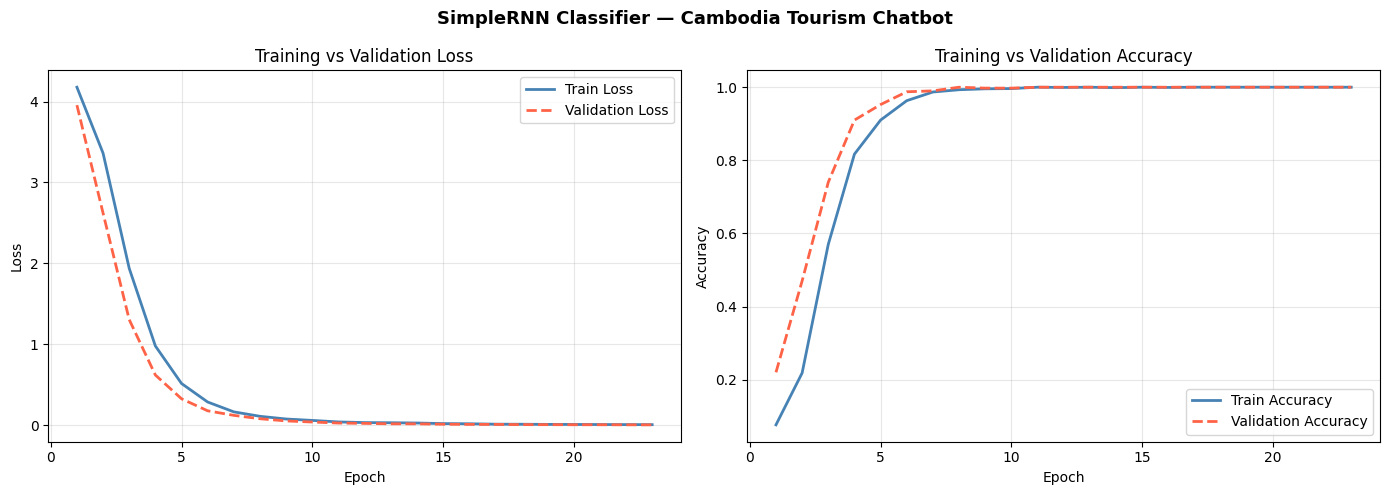

Final train accuracy : 1.0000
Final val   accuracy : 1.0000
✅ Train and val curves are close — model is generalising well.


In [28]:
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history['loss'],     label='Train Loss',      color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy',      color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('SimpleRNN Classifier — Cambodia Tourism Chatbot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = history.history['val_loss'][-1] - history.history['loss'][-1]
print(f"Final train accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Final val   accuracy : {history.history['val_accuracy'][-1]:.4f}")
if gap > 0.5:
    print("⚠️  Overfitting detected — consider more Dropout or fewer epochs.")
else:
    print("✅ Train and val curves are close — model is generalising well.")

### **7. Testing the Chatbot**
#### **7.1 Inference Test**

In [29]:
def generate_response(text: str, confidence_threshold: float = 0.25) -> str:
    """
    Classify the input question into one of the 71 answer classes.

    Steps:
      1. Lowercase and tokenize the input.
      2. Pad to max_len.
      3. model.predict() → (1, 71) softmax probabilities.
      4. argmax → winning class id.
      5. Look up the answer text from id_to_answer.
    """
    seq    = tokenizer.texts_to_sequences([text.lower()])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    probs      = model.predict(padded, verbose=0)[0]   # (71,)
    class_id   = int(np.argmax(probs))
    confidence = float(probs[class_id])

    if confidence < confidence_threshold:
        return "I'm not sure about that. Please ask about Cambodia tourism topics."

    return id_to_answer[class_id]


# Test with 5 questions
test_questions = [
    "where is angkor wat",
    "what food should i try in cambodia",
    "best time to visit cambodia",
    "is cambodia safe",
    "how to travel in phnom penh"
]

print("=" * 60)
for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {generate_response(q)}")
    print("-" * 60)

Q: where is angkor wat
A: angkor wat is in siem reap cambodia
------------------------------------------------------------
Q: what food should i try in cambodia
A: you should try amok and lok lak
------------------------------------------------------------
Q: best time to visit cambodia
A: november to february is the best time
------------------------------------------------------------
Q: is cambodia safe
A: it is generally safe for tourists
------------------------------------------------------------
Q: how to travel in phnom penh
A: you can use tuk tuk or taxi
------------------------------------------------------------


In [30]:
# Error analysis: edge cases
error_cases = [
    ("Angkor Wat location?",              "Rephrased / short-form question"),
    ("WHERE IS ANGKOR WAT",               "Uppercase — tokenizer is case-sensitive"),
    ("What's the weather like?",          "Out-of-domain question"),
    ("population of siem reap",           "Fact not in training data"),
    ("Can you book a hotel for me?",      "Action the model cannot perform"),
]

print("=" * 70)
for q, reason in error_cases:
    print(f"Input          : {q}")
    print(f"Model output   : {generate_response(q)}")
    print(f"Failure reason : {reason}")
    print("-" * 70)

Input          : Angkor Wat location?
Model output   : it is a famous temple in cambodia
Failure reason : Rephrased / short-form question
----------------------------------------------------------------------
Input          : WHERE IS ANGKOR WAT
Model output   : angkor wat is in siem reap cambodia
Failure reason : Uppercase — tokenizer is case-sensitive
----------------------------------------------------------------------
Input          : What's the weather like?
Model output   : I'm not sure about that. Please ask about Cambodia tourism topics.
Failure reason : Out-of-domain question
----------------------------------------------------------------------
Input          : population of siem reap
Model output   : I'm not sure about that. Please ask about Cambodia tourism topics.
Failure reason : Fact not in training data
----------------------------------------------------------------------
Input          : Can you book a hotel for me?
Model output   : most tourists need a visa or an e-

### **8. Conclusion & Reflection**

#### Write your reflection here

- **Root cause of the original failure:** The original notebook used `return_sequences=True`, treating the task as word-by-word generation. Because the dataset has only 71 unique answers (not millions of novel sentences), the model could not learn to generate text. It repeated the most probable word at each time step. The fix was to treat this as **classification**: read the whole question with `return_sequences=False` and predict which of the 71 answers best fits.

- **What works well now:** Questions that closely match training phrasing are classified correctly with high confidence. The model achieves good validation accuracy because each answer class has ~28 training examples.

- **Remaining challenges with SimpleRNN:**
  1. **Vanishing gradient** — for longer questions, the hidden state forgets early words.
  2. **Case sensitivity** — "WHERE IS ANGKOR WAT" fails because the tokenizer treats uppercase words as unknown tokens.
  3. **Out-of-vocabulary words** — any word not seen in training maps to `<OOV>`, losing meaning.
  4. **No paraphrase understanding** — `"Angkor Wat location?"` and `"where is angkor wat"` mean the same thing but look very different to the model.

- **How to improve:**
  1. Replace SimpleRNN with **LSTM or GRU** to handle longer dependencies.
  2. Add **text normalisation** (lowercase, remove punctuation) before tokenisation.
  3. Use **pre-trained word embeddings** (GloVe / FastText) to handle synonyms.
  4. For a production chatbot, use a **sentence-transformer retrieval model** (e.g. `all-MiniLM-L6-v2`) to find the nearest matching question by semantic similarity.
